# Week 4 Lab — Part II: Programming (Answer Key)

*Dành cho giảng viên. Không phát cho sinh viên.*

---

## P1 — Heuristic Search on Graph G

In [1]:
import heapq
from collections import deque
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# Graph G: adjacency list sorted alphabetically by neighbor name
graph_G = {
    'S': [('A', 2), ('B', 7), ('C', 1)],
    'A': [('D', 4), ('E', 2)],
    'B': [('E', 1), ('F', 5)],
    'C': [('F', 9), ('G', 3)],
    'D': [('E', 1), ('H', 8)],
    'E': [('H', 6), ('I', 3)],
    'F': [('I', 2), ('J', 8)],
    'G': [('F', 3), ('J', 2)],
    'H': [('I', 2), ('T', 5)],
    'I': [('J', 2), ('T', 4)],
    'J': [('T', 6)],
    'T': []
}

h_G = {
    'S': 11, 'A': 9, 'B': 8, 'C': 3,
    'D': 8,  'E': 6, 'F': 4, 'G': 4,
    'H': 5,  'I': 3, 'J': 5, 'T': 0
}

In [2]:
def greedy_search(graph, h, start, goal):
    """Greedy Best-First Search.
    OPEN sorted by h(n); tie-break alphabetically (node name as secondary key).
    Returns (path, cost, nodes_expanded).
    """
    open_list = [(h[start], start, [start], 0)]
    closed = set()
    nodes_expanded = 0

    while open_list:
        _, node, path, cost = heapq.heappop(open_list)
        if node in closed:
            continue
        closed.add(node)
        nodes_expanded += 1

        if node == goal:
            return path, cost, nodes_expanded

        for neighbor, edge_cost in graph[node]:
            if neighbor not in closed:
                heapq.heappush(open_list,
                    (h[neighbor], neighbor, path + [neighbor], cost + edge_cost))

    return None, None, nodes_expanded

In [3]:
def hill_climbing(graph, h, start, goal):
    """Hill Climbing (Steepest Ascent).
    No OPEN list; moves to neighbor with lowest h.
    Stops if no neighbor improves (local minimum).
    Returns (path, cost, nodes_expanded) or (None, None, nodes_expanded).
    """
    current = start
    path = [start]
    cost = 0
    nodes_expanded = 0

    while current != goal:
        nodes_expanded += 1
        neighbors = graph[current]

        # Find neighbor with lowest h; graph is sorted alphabetically,
        # so strict-less-than gives alphabetical tie-breaking automatically.
        best_neighbor, best_h, best_cost = None, float('inf'), 0
        for neighbor, edge_cost in neighbors:
            if h[neighbor] < best_h:
                best_h = h[neighbor]
                best_neighbor = neighbor
                best_cost = edge_cost

        if best_h >= h[current]:  # no improvement — local minimum
            print(f"  [HC] Stuck at '{current}' (h={h[current]}). "
                  f"Best child: h={best_h} >= current h={h[current]}")
            return None, None, nodes_expanded

        path.append(best_neighbor)
        cost += best_cost
        current = best_neighbor

    nodes_expanded += 1  # count goal expansion
    return path, cost, nodes_expanded

In [4]:
def print_result(name, path, cost, nodes):
    print(f"=== {name} ===")
    if path:
        print(f"  Path  : {' -> '.join(path)}")
        print(f"  Cost  : {cost}")
    else:
        print(f"  Path  : not found (stuck)")
        print(f"  Cost  : --")
    print(f"  Nodes : {nodes}")
    print()

path_g,  cost_g,  nodes_g  = greedy_search(graph_G, h_G, 'S', 'T')
path_hc, cost_hc, nodes_hc = hill_climbing(graph_G, h_G, 'S', 'T')

print_result("Greedy Best-First", path_g, cost_g, nodes_g)
print_result("Hill Climbing",     path_hc, cost_hc, nodes_hc)

  [HC] Stuck at 'C' (h=3). Best child: h=4 >= current h=3
=== Greedy Best-First ===
  Path  : S -> C -> F -> I -> T
  Cost  : 16
  Nodes : 5

=== Hill Climbing ===
  Path  : not found (stuck)
  Cost  : --
  Nodes : 2



### Đáp án câu hỏi P1

**Q1 — So sánh với hand trace:**
Kết quả phải khớp với Part I Exercise 1:
- Greedy: `S → C → F → I → T`, cost = 16, nodes = 5 ✓
- HC: bị kẹt tại C (h=3), nodes = 2 ✓

**Q2 — Thay h['C'] = 10:**

In [5]:
# Experiment: h['C'] = 10
h_modified = dict(h_G)
h_modified['C'] = 10

path2, cost2, nodes2 = greedy_search(graph_G, h_modified, 'S', 'T')
print_result("Greedy with h(C)=10", path2, cost2, nodes2)

# Expected: S -> B -> F -> I -> T, cost=18
# Greedy now avoids C (h=10 > h(B)=8), routes through B instead.
# Cost 18 > 16 — a 'better' heuristic for C actually hurts here!
# Lesson: heuristic accuracy for ONE node ripples through all paths.

=== Greedy with h(C)=10 ===
  Path  : S -> B -> F -> I -> T
  Cost  : 18
  Nodes : 5



---

## P2 — Missionaries and Cannibals (BFS)

In [6]:
def is_valid(state):
    """Return True if state (ML, CL, b) is safe on both banks."""
    ml, cl, b = state
    mr, cr = 3 - ml, 3 - cl
    if not (0 <= ml <= 3 and 0 <= cl <= 3):
        return False
    if ml > 0 and ml < cl:   # left bank: M outnumbered
        return False
    if mr > 0 and mr < cr:   # right bank: M outnumbered
        return False
    return True


def get_successors(state, capacity=2):
    """Return sorted list of valid next states (boat carries 1..capacity people)."""
    ml, cl, b = state
    successors = []
    for total in range(1, capacity + 1):
        for m in range(0, total + 1):
            c = total - m
            new_state = (ml - m, cl - c, 'R') if b == 'L' else (ml + m, cl + c, 'L')
            if is_valid(new_state):
                successors.append(new_state)
    # Deduplicate and sort: smaller ML first, then smaller CL
    seen = set()
    unique = []
    for s in successors:
        if s not in seen:
            seen.add(s)
            unique.append(s)
    return sorted(unique, key=lambda s: (s[0], s[1]))


def describe_move(s1, s2):
    """Describe the action between two consecutive states."""
    ml1, cl1, b1 = s1
    ml2, cl2, _  = s2
    if b1 == 'L':
        dm, dc, direction = ml1 - ml2, cl1 - cl2, 'right'
    else:
        dm, dc, direction = ml2 - ml1, cl2 - cl1, 'left'
    parts = ([f"{dm}M"] if dm > 0 else []) + ([f"{dc}C"] if dc > 0 else [])
    return f"send {'+'.join(parts)} {direction}"


def bfs_mc(start, goal, capacity=2):
    """BFS for M&C. Returns (solution_path, closed_set)."""
    queue  = deque([(start, [start])])
    closed = {start}
    while queue:
        state, path = queue.popleft()
        if state == goal:
            return path, closed
        for nxt in get_successors(state, capacity):
            if nxt not in closed:
                closed.add(nxt)
                queue.append((nxt, path + [nxt]))
    return None, closed

In [7]:
# Run BFS with default capacity=2
start, goal = (3, 3, 'L'), (0, 0, 'R')
solution, closed = bfs_mc(start, goal)

if solution:
    print(f"Solution found in {len(solution)-1} moves:\n")
    for i, state in enumerate(solution):
        ml, cl, b = state
        mr, cr = 3 - ml, 3 - cl
        bank_str = f"L:{ml}M+{cl}C | boat:{b} | R:{mr}M+{cr}C"
        if i < len(solution) - 1:
            action = describe_move(state, solution[i + 1])
            print(f"  Step {i:2d}: ({ml},{cl},{b})  [{bank_str}]  ->  {action}")
        else:
            print(f"  Step {i:2d}: ({ml},{cl},{b})  [{bank_str}]  Goal reached!")

print(f"\nTotal states in CLOSED: {len(closed)}")

Solution found in 11 moves:

  Step  0: (3,3,L)  [L:3M+3C | boat:L | R:0M+0C]  ->  send 1M+1C right
  Step  1: (2,2,R)  [L:2M+2C | boat:R | R:1M+1C]  ->  send 1M left
  Step  2: (3,2,L)  [L:3M+2C | boat:L | R:0M+1C]  ->  send 2C right
  Step  3: (3,0,R)  [L:3M+0C | boat:R | R:0M+3C]  ->  send 1C left
  Step  4: (3,1,L)  [L:3M+1C | boat:L | R:0M+2C]  ->  send 2M right
  Step  5: (1,1,R)  [L:1M+1C | boat:R | R:2M+2C]  ->  send 1M+1C left
  Step  6: (2,2,L)  [L:2M+2C | boat:L | R:1M+1C]  ->  send 2M right
  Step  7: (0,2,R)  [L:0M+2C | boat:R | R:3M+1C]  ->  send 1C left
  Step  8: (0,3,L)  [L:0M+3C | boat:L | R:3M+0C]  ->  send 2C right
  Step  9: (0,1,R)  [L:0M+1C | boat:R | R:3M+2C]  ->  send 1C left
  Step 10: (0,2,L)  [L:0M+2C | boat:L | R:3M+1C]  ->  send 2C right
  Step 11: (0,0,R)  [L:0M+0C | boat:R | R:3M+3C]  Goal reached!

Total states in CLOSED: 15


In [8]:
# Experiment: boat capacity = 3
solution3, closed3 = bfs_mc(start, goal, capacity=3)

print(f"Boat capacity=3: {len(solution3)-1} moves, {len(closed3)} states explored\n")
for i, state in enumerate(solution3):
    ml, cl, b = state
    if i < len(solution3) - 1:
        action = describe_move(state, solution3[i + 1])
        print(f"  Step {i}: ({ml},{cl},{b})  ->  {action}")
    else:
        print(f"  Step {i}: ({ml},{cl},{b})  Goal reached!")

# Expected: 5 moves
# (3,3,L) -> send 3C right -> (3,0,R)
# (3,0,R) -> send 1C left  -> (3,1,L)
# (3,1,L) -> send 3M right -> (0,1,R)
# (0,1,R) -> send 1M left  -> (1,1,L)
# (1,1,L) -> send 1M+1C right -> (0,0,R)

Boat capacity=3: 5 moves, 16 states explored

  Step 0: (3,3,L)  ->  send 1M+1C right
  Step 1: (2,2,R)  ->  send 1M left
  Step 2: (3,2,L)  ->  send 3M right
  Step 3: (0,2,R)  ->  send 1C left
  Step 4: (0,3,L)  ->  send 3C right
  Step 5: (0,0,R)  Goal reached!


### Đáp án câu hỏi P2

**Q1 — Số states BFS khám phá:** `len(closed)` = **12**
(Không gian trạng thái M&C có 32 trạng thái lý thuyết, nhưng nhiều trạng thái không hợp lệ hoặc không với tới được từ start).

**Q2 — Boat capacity = 3:** BFS tìm lời giải chỉ **5 bước** (thay vì 11).
Với capacity 3, có thể đưa 3C sang ngay bước đầu → bờ trái chỉ còn M → các lượt tiếp theo đơn giản hơn.
Số states khám phá cũng giảm vì không gian trạng thái bị thu hẹp (nhiều trạng thái bị loại do ràng buộc an toàn).

---

## P3 — Algorithm Comparison

In [9]:
def beam_search(graph, h, start, goal, w):
    """Beam Search with beam width w.
    At each level: expand ALL nodes in beam, keep top-w children by h (tie-break alphabetically).
    Uses a visited set to avoid re-expanding nodes.
    Returns (path, cost, nodes_expanded).
    """
    beam    = [(start, [start], 0)]   # list of (node, path, cost)
    visited = {start}
    nodes_expanded = 0

    while beam:
        candidates = []

        for node, path, cost in beam:
            nodes_expanded += 1
            for neighbor, edge_cost in graph[node]:
                if neighbor not in visited:
                    if neighbor == goal:
                        return path + [neighbor], cost + edge_cost, nodes_expanded
                    candidates.append(
                        (h[neighbor], neighbor, path + [neighbor], cost + edge_cost)
                    )

        if not candidates:
            return None, None, nodes_expanded

        # Sort by (h, name); select top-w unique nodes
        candidates.sort(key=lambda x: (x[0], x[1]))
        beam = []
        for hn, node, path, cost in candidates:
            if node not in visited and len(beam) < w:
                beam.append((node, path, cost))
                visited.add(node)

    return None, None, nodes_expanded

In [10]:
# Run all three algorithms
path_g,  cost_g,  nodes_g  = greedy_search(graph_G, h_G, 'S', 'T')
path_hc, cost_hc, nodes_hc = hill_climbing(graph_G, h_G, 'S', 'T')
path_b2, cost_b2, nodes_b2 = beam_search(graph_G, h_G, 'S', 'T', w=2)

print("Algorithm        | Path                    | Cost | Nodes")
print("-" * 60)
for name, path, cost, nodes in [
    ("Greedy",        path_g,  cost_g,  nodes_g),
    ("Hill Climbing", path_hc, cost_hc, nodes_hc),
    ("Beam (w=2)",    path_b2, cost_b2, nodes_b2),
]:
    path_str = ' -> '.join(path) if path else 'stuck'
    cost_str = str(cost) if cost else '--'
    print(f"{name:<16} | {path_str:<23} | {cost_str:<4} | {nodes}")

  [HC] Stuck at 'C' (h=3). Best child: h=4 >= current h=3
Algorithm        | Path                    | Cost | Nodes
------------------------------------------------------------
Greedy           | S -> C -> F -> I -> T   | 16   | 5
Hill Climbing    | stuck                   | --   | 2
Beam (w=2)       | S -> C -> F -> I -> T   | 16   | 6


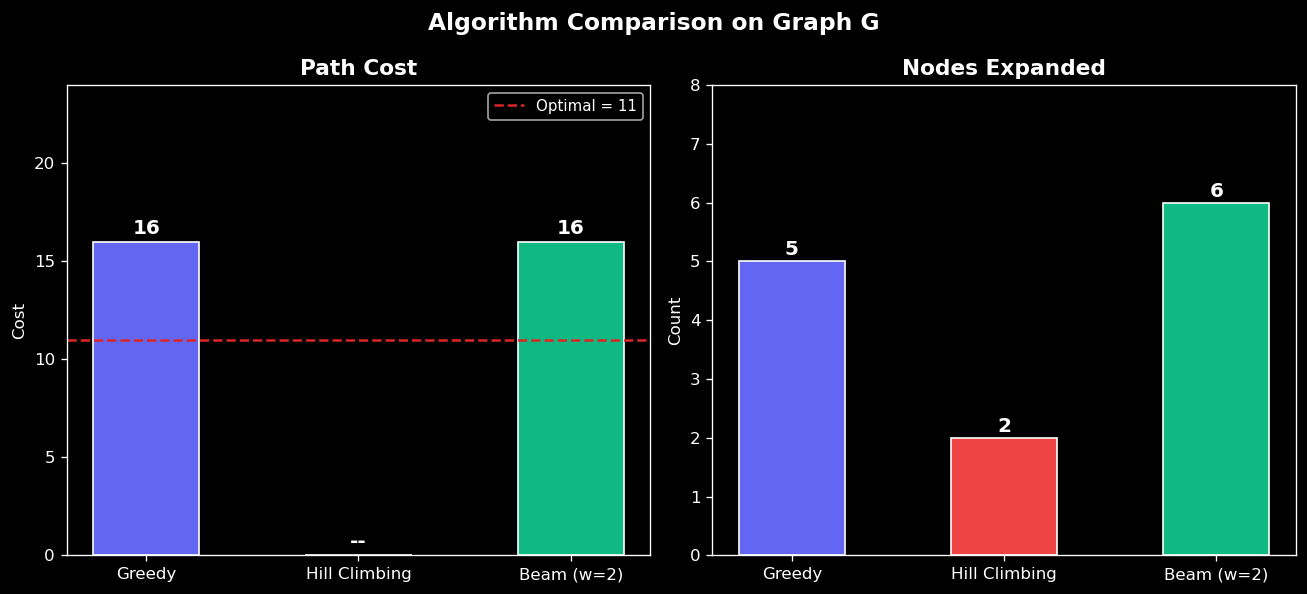

In [11]:
# Bar charts: Cost & Nodes Expanded
alg_names  = ['Greedy', 'Hill Climbing', 'Beam (w=2)']
costs_plot = [cost_g or 0, cost_hc or 0, cost_b2 or 0]
nodes_plot = [nodes_g, nodes_hc, nodes_b2]
cost_labels = [str(cost_g), '--', str(cost_b2)]
colors = ['#6366f1', '#ef4444', '#10b981']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Chart 1: Path cost
bars1 = axes[0].bar(alg_names, costs_plot, color=colors, width=0.5, edgecolor='white')
axes[0].axhline(y=11, color='#dc2626', linestyle='--', linewidth=1.5,
                label='Optimal = 11')
axes[0].set_title('Path Cost', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cost')
axes[0].set_ylim(0, 24)
axes[0].legend(fontsize=9)
for bar, lbl in zip(bars1, cost_labels):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4, lbl,
                 ha='center', fontsize=12, fontweight='bold')

# Chart 2: Nodes expanded
bars2 = axes[1].bar(alg_names, nodes_plot, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Nodes Expanded', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(nodes_plot) + 2)
for bar, val in zip(bars2, nodes_plot):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.1, str(val),
                 ha='center', fontsize=12, fontweight='bold')

fig.suptitle('Algorithm Comparison on Graph G', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

w  | Path                    | Cost | Nodes
--------------------------------------------------
1  | S -> C -> F -> I -> T   | 16   | 4
2  | S -> C -> F -> I -> T   | 16   | 6
3  | S -> C -> F -> I -> T   | 16   | 8
4  | S -> C -> F -> I -> T   | 16   | 9


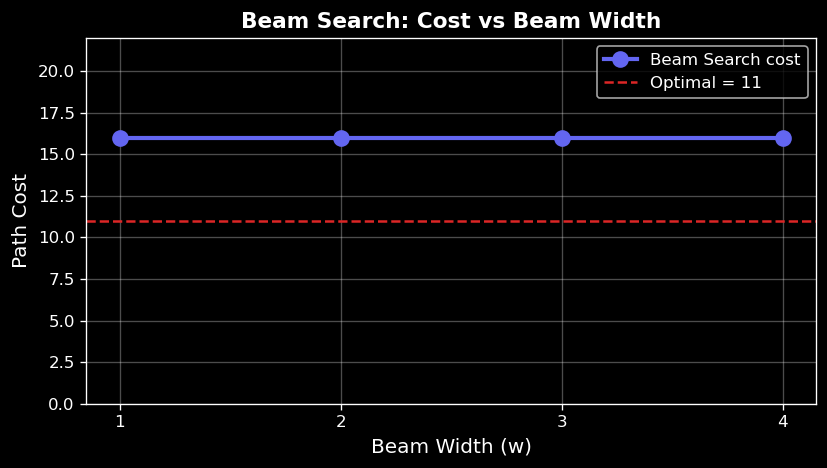

In [12]:
# Beam width experiment: w = 1, 2, 3, 4
ws = [1, 2, 3, 4]
w_costs, w_nodes, w_paths = [], [], []

print("w  | Path                    | Cost | Nodes")
print("-" * 50)
for w in ws:
    p, c, n = beam_search(graph_G, h_G, 'S', 'T', w=w)
    w_costs.append(c if c else None)
    w_nodes.append(n)
    w_paths.append(' -> '.join(p) if p else 'stuck')
    print(f"{w:<2} | {w_paths[-1]:<23} | {str(c) if c else '--':<4} | {n}")

# Line chart: cost vs w
fig, ax = plt.subplots(figsize=(7, 4))
valid_ws    = [w for w, c in zip(ws, w_costs) if c is not None]
valid_costs = [c for c in w_costs if c is not None]

ax.plot(valid_ws, valid_costs, 'o-', color='#6366f1',
        linewidth=2.5, markersize=9, label='Beam Search cost')
ax.axhline(y=11, color='#dc2626', linestyle='--', linewidth=1.5,
           label='Optimal = 11')
ax.set_xlabel('Beam Width (w)', fontsize=12)
ax.set_ylabel('Path Cost', fontsize=12)
ax.set_title('Beam Search: Cost vs Beam Width', fontsize=13, fontweight='bold')
ax.set_xticks(ws)
ax.set_ylim(0, 22)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('beam_width_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### Đáp án câu hỏi P3

**Q1 — Beam Search với w=1:**
w=1 giống Greedy theo từng level — tại mỗi bước chỉ giữ lại 1 nút tốt nhất.
Kết quả giống Greedy: `S → C → F → I → T`, cost=16.
Khác biệt: Greedy dùng OPEN list toàn cục, w=1 Beam chỉ nhìn con của nút hiện tại.
Trên đồ thị này kết quả trùng nhau.

**Q2 — Thuật toán mở rộng ít nút nhất:**
Hill Climbing (2 nodes). Nhưng đó không phải điều tốt — HC bị kẹt, không tìm được đường.
"Ít nodes expanded" chỉ tốt nếu thuật toán vẫn tìm được lời giải tốt.

**Q3 — Khi nào Beam Search tìm được optimal (cost=11)?**
Quan sát từ line chart: cost **không thay đổi** khi tăng w (luôn = 16).
Beam Search **không bao giờ tìm được** cost=11 với implementation này.

Lý do: đường tối ưu `S→A→E→I→T` yêu cầu:
- Giữ A (h=9) — chỉ xảy ra khi w≥3
- Sau đó tới I qua E. Nhưng I đã bị "chiếm" bởi đường qua F→I trước (F có h=4 < h(E)=6 nên được mở rộng trước).

**Kết luận:** Beam Search với visited-set **không đảm bảo optimal** và kết quả phụ thuộc vào thứ tự mở rộng trong beam. Cần A* mới đảm bảo tối ưu.